# Network Graph



#### Discriptions of variables
- supply: actual generation output at the bus in MW (Act.P[MW]) supplyb​=g∈generators at bus b ∑​ Act.Pg​
- demand: the total active power consumption in MW assigned to a bus, based on the aggregated load entries in the Load sheet. demandb​=l∈loads at bus b ∑ ​Act.P
- p_min: minimum generation level at the bus in MW
- p_max: maximum generation capacity at the bus in MW
- source: generation technology type(s) connected to the bus (wind, sollar...)
- node_role: whether the bus functions as generator, load, both, or neither
- capacity≈ squareroot(3)⋅VkV​⋅IkA​

### Use the object without haveing to run the jupyter: 

In [73]:
import pickle

with open("network_graph.pkl", "rb") as f:
    G = pickle.load(f)

### Loading pakages

In [74]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

### Loading raw data 

In [75]:
file_path = "publicdataexportv131450706334_with_lon_lat.xlsx"

def to_num(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


# Loading sheets
bus = pd.read_excel(file_path, sheet_name="Bus", header=3)
line = pd.read_excel(file_path, sheet_name="Line", header=3)
gen = pd.read_excel(file_path, sheet_name="Generator", header=3)
load = pd.read_excel(file_path, sheet_name="Load", header=3)
hvdc = pd.read_excel(file_path, sheet_name="HVDC", header=3)
transformer2 = pd.read_excel(file_path, sheet_name="Transformer2", header=3)
transformer3 = pd.read_excel(file_path, sheet_name="Transformer3", header=3)

for df in [bus, line, gen, load, hvdc, transformer2, transformer3]:
    df.columns = [str(c).strip() for c in df.columns]


### Clean transformers

In [76]:
# Cleaning transformer2
transformer2["High.V Bus Index"] = pd.to_numeric(transformer2["High.V Bus Index"], errors="coerce")
transformer2["Low.V Bus Index"] = pd.to_numeric(transformer2["Low.V Bus Index"], errors="coerce")

t2_edges = transformer2.rename(columns={
    "High.V Bus Index": "node1",
    "Low.V Bus Index": "node2"
}).copy()

t2_edges = t2_edges.dropna(subset=["node1", "node2"])
t2_edges["node1"] = t2_edges["node1"].astype(int)
t2_edges["node2"] = t2_edges["node2"].astype(int)

t2_edges["name"] = "transformer2"
t2_edges["capacity"] = np.nan


# Cleaning transformer3
transformer3["High.V Bus Index"] = pd.to_numeric(transformer3["High.V Bus Index"], errors="coerce")
transformer3["Mid.V Bus Index"] = pd.to_numeric(transformer3["Mid.V Bus Index"], errors="coerce")
transformer3["Low.V Bus Index"] = pd.to_numeric(transformer3["Low.V Bus Index"], errors="coerce")

t3_list = []

for _, row in transformer3.iterrows():
    h = row["High.V Bus Index"]
    m = row["Mid.V Bus Index"]
    l = row["Low.V Bus Index"]

    if pd.notna(h) and pd.notna(m):
        t3_list.append((int(h), int(m)))
    if pd.notna(m) and pd.notna(l):
        t3_list.append((int(m), int(l)))

t3_edges = pd.DataFrame(t3_list, columns=["node1", "node2"])

t3_edges["name"] = "transformer3"
t3_edges["capacity"] = np.nan

### Cleaning "bus" (first sheet) and creating nodes

In [77]:
bus["Bus Index"] = pd.to_numeric(bus["Bus Index"], errors="coerce")
bus["lon"] = pd.to_numeric(bus["lon"], errors="coerce")
bus["lat"] = pd.to_numeric(bus["lat"], errors="coerce")
bus["Voltage base[kV]"] = to_num(bus["Voltage base[kV]"])

nodes = bus[[
    "Bus Index",
    "Bus Name",
    "Station Full Name",
    "Location Name",
    "Voltage base[kV]",
    "lon",
    "lat"
]].copy()


nodes = nodes.rename(columns={
    "Bus Index": "bus_index",
    "Bus Name": "bus_name",
    "Station Full Name": "station_full_name",
    "Location Name": "area_code",
    "Voltage base[kV]": "voltage_kv"
})

nodes = nodes.dropna(subset=["bus_index"]).drop_duplicates(subset=["bus_index"])
nodes["bus_index"] = nodes["bus_index"].astype(int)

# name = station_full_name hvis den findes, ellers bus_name
nodes["name"] = nodes["station_full_name"].fillna("").astype(str).str.strip()
nodes.loc[nodes["name"] == "", "name"] = nodes["bus_name"]

#### We aggregate the generator sheet from unit level to bus level by grouping all generators connected to the same bus and summing their actual output, minimum output, and maximum capacity, so that each graph node can carry total generation attributes in MW.

In [78]:
gen["Bus Index"] = pd.to_numeric(gen["Bus Index"], errors="coerce")
gen["Pmin[MW]"] = to_num(gen["Pmin[MW]"])
gen["Pmax[MW]"] = to_num(gen["Pmax[MW]"])
gen["Act.P[MW]"] = to_num(gen["Act.P[MW]"])

# --- classify source type from Generator Name ---
def classify_generator_source(name):
    if pd.isna(name):
        return "unknown"
    name = str(name).lower()

    if "windoff" in name:
        return "wind_offshore"
    elif "windon" in name:
        return "wind_onshore"
    elif "solar" in name:
        return "solar"
    elif "gas" in name:
        return "gas"
    elif "hydro" in name:
        return "hydro"
    elif "other" in name:
        return "other"
    else:
        return "unknown"

gen["gen_source"] = gen["Generator Name"].apply(classify_generator_source)

# --- aggregate MW values by bus ---
gen_agg = (
    gen.groupby("Bus Index", dropna=False)
    .agg(
        supply=("Act.P[MW]", "sum"),
        p_min=("Pmin[MW]", "sum"),
        p_max=("Pmax[MW]", "sum")
    )
    .reset_index()
    .rename(columns={"Bus Index": "bus_index"})
)

gen_agg["bus_index"] = pd.to_numeric(gen_agg["bus_index"], errors="coerce")
gen_agg = gen_agg.dropna(subset=["bus_index"])
gen_agg["bus_index"] = gen_agg["bus_index"].astype(int)

# --- aggregate source types by bus ---
source_agg = (
    gen.groupby("Bus Index")["gen_source"]
    .apply(lambda x: ", ".join(sorted(set(v for v in x.dropna() if v != "unknown"))))
    .reset_index()
    .rename(columns={
        "Bus Index": "bus_index",
        "gen_source": "source"
    })
)

source_agg["bus_index"] = pd.to_numeric(source_agg["bus_index"], errors="coerce")
source_agg = source_agg.dropna(subset=["bus_index"])
source_agg["bus_index"] = source_agg["bus_index"].astype(int)

# hvis en bus kun havde ukendte generatornavne, så bliver source tom
source_agg["source"] = source_agg["source"].replace("", np.nan)

### Aggregating the load sheet to bus level by grouping all load entries assigned to the same bus, summing their actual active power values, and storing the result as positive MW demand for each graph node.

In [79]:
# Assumption: Load Index corresponds to Bus Index
load["Load Index"] = pd.to_numeric(load["Load Index"], errors="coerce")
load["Act.P[MW]"] = to_num(load["Act.P[MW]"])

load_agg = (
    load.groupby("Load Index", dropna=False)
    .agg(demand=("Act.P[MW]", "sum"))
    .reset_index()
    .rename(columns={"Load Index": "bus_index"})
)

load_agg["bus_index"] = pd.to_numeric(load_agg["bus_index"], errors="coerce")
load_agg = load_agg.dropna(subset=["bus_index"])
load_agg["bus_index"] = load_agg["bus_index"].astype(int)

# Make demand positive for consumption
# If a load entry is negative (e.g. foreign/border convention), take abs
load_agg["demand"] = load_agg["demand"].abs()

### Merging nodes attributes
#### We merge the aggregated generation and load summaries onto the bus-level node table, replace missing values with zero for buses without attached generation or demand, classify each bus by functional role, and retain the final set of node attributes used in the graph model.

In [80]:
nodes = nodes.merge(gen_agg, on="bus_index", how="left")
nodes = nodes.merge(load_agg, on="bus_index", how="left")
nodes = nodes.merge(source_agg, on="bus_index", how="left")


for col in ["supply", "p_min", "p_max", "demand"]:
    nodes[col] = nodes[col].fillna(0.0)

def classify_node_role(row):
    has_gen = row["p_max"] > 0
    has_load = row["demand"] > 0
    
    if has_gen and has_load:
        return "generator+load"
    elif has_gen:
        return "generator"
    elif has_load:
        return "load"
    else:
        return "none"

nodes["node_role"] = nodes.apply(classify_node_role, axis=1)


nodes_final = nodes[[
    "bus_index",
    "name",
    "supply",
    "demand",
    "p_min",
    "p_max",
    "node_role",
    "source",
    "bus_name",
    "station_full_name",
    "area_code",
    "voltage_kv",
    "lat",
    "lon"
]].copy()

#### Making edges

In [81]:
line["Node 1"] = pd.to_numeric(line["Node 1"], errors="coerce")
line["Node 2"] = pd.to_numeric(line["Node 2"], errors="coerce")
line["Nominal Current[kA]"] = to_num(line["Nominal Current[kA]"])
line["Nominal Voltage[kV]"] = to_num(line["Nominal Voltage[kV]"])

edges = line.rename(columns={
    "Node 1": "node1",
    "Node 2": "node2",
    "Line name": "name"
}).copy()

edges = edges.dropna(subset=["node1", "node2"]).copy()
edges["node1"] = edges["node1"].astype(int)
edges["node2"] = edges["node2"].astype(int)

# Approximate edge capacity in MW from line rating
# capacity ≈ sqrt(3) * V[kV] * I[kA]
edges["capacity"] = np.sqrt(3) * edges["Nominal Voltage[kV]"] * edges["Nominal Current[kA]"]

edges_final = edges[[
    "node1",
    "node2",
    "name",
    "capacity",
    "Area Name",
    "Line type",
    "Nominal Voltage[kV]",
    "Nominal Current[kA]",
    "R1[Ohm]",
    "X1[Ohm]",
    "Length[km]"
]].copy()

# Renname columns to more consistent names
edges_final = edges_final.rename(columns={
    "Area Name": "area_code",
    "Line type": "line_type",
    "Nominal Voltage[kV]": "voltage_kv",
    "Nominal Current[kA]": "nominal_current_ka",
    "R1[Ohm]": "r_ohm",
    "X1[Ohm]": "x_ohm",
    "Length[km]": "length_km"
})

edges_final["edge_type"] = "line"


# Transformer2
t2_edges_clean = t2_edges.copy()

t2_edges_clean["area_code"] = None
t2_edges_clean["line_type"] = "transformer"
t2_edges_clean["voltage_kv"] = None
t2_edges_clean["nominal_current_ka"] = None
t2_edges_clean["r_ohm"] = None
t2_edges_clean["x_ohm"] = None
t2_edges_clean["length_km"] = None
t2_edges_clean["edge_type"] = "transformer"


# Transformer3
t3_edges_clean = t3_edges.copy()

t3_edges_clean["area_code"] = None
t3_edges_clean["line_type"] = "transformer"
t3_edges_clean["voltage_kv"] = None
t3_edges_clean["nominal_current_ka"] = None
t3_edges_clean["r_ohm"] = None
t3_edges_clean["x_ohm"] = None
t3_edges_clean["length_km"] = None
t3_edges_clean["edge_type"] = "transformer"


# Combine all edges
edges_final = pd.concat([
    edges_final,
    t2_edges_clean,
    t3_edges_clean
], ignore_index=True)

C:\Users\Baxe\AppData\Local\Temp\ipykernel_34692\3663502622.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges_final = pd.concat([


#### Saving clean tables

In [82]:
out_file = "danish_grid_graph_ready.xlsx"
with pd.ExcelWriter(out_file, engine="openpyxl") as writer:
    nodes_final.to_excel(writer, sheet_name="nodes", index=False)
    edges_final.to_excel(writer, sheet_name="edges", index=False)

print(f"Saved graph-ready dataset to {out_file}")
print("Nodes:", nodes_final.shape)
print("Edges:", edges_final.shape)



Saved graph-ready dataset to danish_grid_graph_ready.xlsx
Nodes: (300, 14)
Edges: (438, 31)


#### Building the network graph


In [83]:
G = nx.Graph()

# add nodes
for _, row in nodes_final.iterrows():
    G.add_node(
        int(row["bus_index"]),
        name=row["name"],
        supply=float(row["supply"]),
        demand=float(row["demand"]),
        p_min=float(row["p_min"]),
        p_max=float(row["p_max"]),
        source=row["source"]
    )

# add edges
for _, row in edges_final.iterrows():
    G.add_edge(
        int(row["node1"]),
        int(row["node2"]),
        name=row["name"],
        capacity=float(row["capacity"]) if pd.notna(row["capacity"]) else 0.0
    )

print("Graph created.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Optional sanity check
sample_node = list(G.nodes(data=True))[:5]
sample_edge = list(G.edges(data=True))[:5]

print("\nSample nodes:")
for x in sample_node:
    print(x)

print("\nSample edges:")
for x in sample_edge:
    print(x)


Graph created.
Number of nodes: 300
Number of edges: 396

Sample nodes:
(76, {'name': 'Bjæverskov', 'supply': 0.0, 'demand': 0.0, 'p_min': 0.0, 'p_max': 0.0, 'source': nan})
(192, {'name': '150 KV STATION ABILDSKOV', 'supply': 27.47, 'demand': 33.9, 'p_min': 0.0, 'p_max': 75.69, 'source': 'gas, hydro, solar, wind_onshore'})
(194, {'name': '150 KV STATION ÅDALEN', 'supply': 3.7899999999999996, 'demand': 44.7, 'p_min': 0.0, 'p_max': 9.94, 'source': 'gas, solar, wind_onshore'})
(195, {'name': 'Anholt Havmøllepark', 'supply': 52.68, 'demand': 0.0, 'p_min': 0.0, 'p_max': 400.0, 'source': 'wind_offshore'})
(53, {'name': '132 KV STATION ALLERØDGÅRD', 'supply': 21.21, 'demand': 58.0, 'p_min': 0.0, 'p_max': 75.0, 'source': 'gas, solar, wind_onshore'})

Sample edges:
(76, 77, {'name': 'transformer2', 'capacity': 0.0})
(76, 78, {'name': 'transformer2', 'capacity': 0.0})
(192, 284, {'name': 'ABS_150_OVE', 'capacity': 220.05705510162588})
(192, 299, {'name': 'ABS_150_SVB_eq_ElmLne', 'capacity': 282

In [87]:
print(G.nodes[101])

{'name': 'Haslev', 'supply': 3.7199999999999998, 'demand': 30.5, 'p_min': 0.0, 'p_max': 32.620000000000005, 'source': 'gas, solar, wind_onshore'}


In [85]:
import pickle

with open("network_graph.pkl", "wb") as f:
    pickle.dump(G, f)

### Network graph

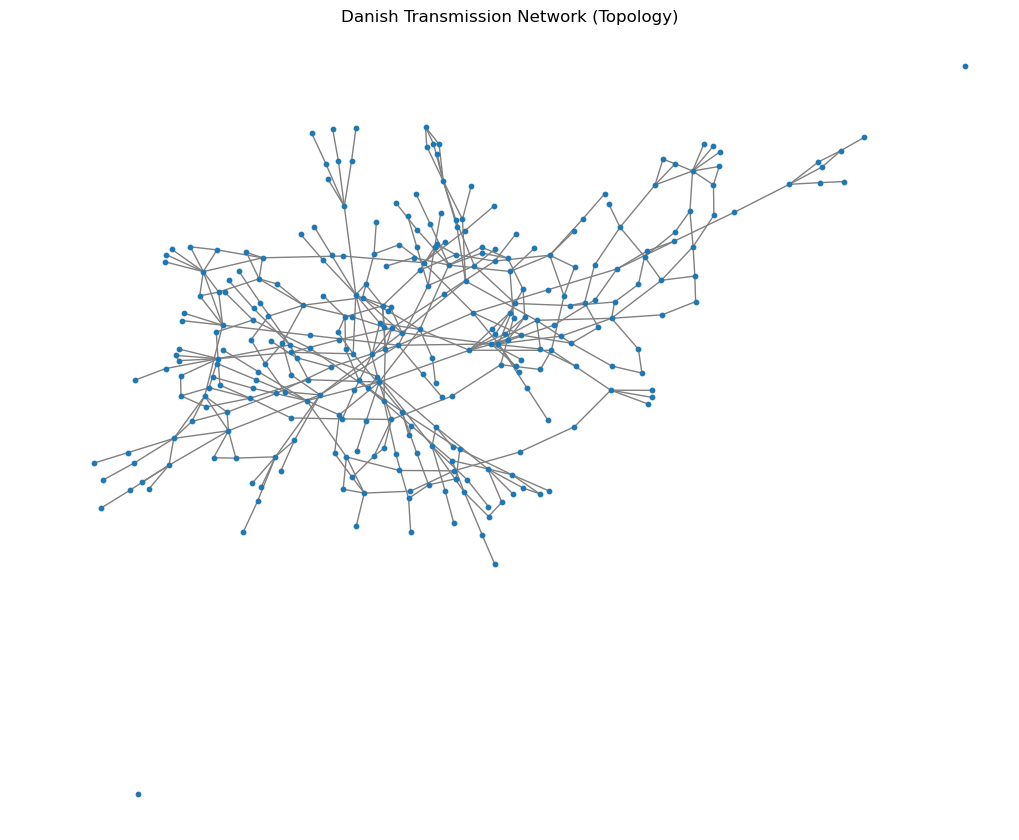

In [86]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)  # layout algorithm

nx.draw(
    G,
    pos,
    node_size=10,
    edge_color="gray",
    with_labels=False
)

plt.title("Danish Transmission Network (Topology)")
plt.show()

In [88]:
import folium
import os
import webbrowser

# Base map (Denmark centered)
m = folium.Map(
    location=[56.2, 10.0],
    zoom_start=7,
    tiles="CartoDB Positron"
)

# -----------------------
# ADD NODES
# -----------------------
for _, row in nodes_final.iterrows():
    if pd.notna(row["lat"]) and pd.notna(row["lon"]):
        popup_text = f"""
        <b>{row['name']}</b><br>
        Supply: {row['supply']:.1f} MW<br>
        Demand: {row['demand']:.1f} MW<br>
        Type: {row['node_role']}
        """

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=4,
            popup=popup_text,
            fill=True,
            fill_opacity=0.8,
            color="blue"
        ).add_to(m)

# -----------------------
# ADD EDGES (LINES)
# -----------------------
for _, row in edges_final.iterrows():
    n1 = nodes_final[nodes_final["bus_index"] == row["node1"]]
    n2 = nodes_final[nodes_final["bus_index"] == row["node2"]]

    if len(n1) > 0 and len(n2) > 0:
        latlon1 = n1.iloc[0][["lat", "lon"]]
        latlon2 = n2.iloc[0][["lat", "lon"]]

        if pd.notna(latlon1["lat"]) and pd.notna(latlon2["lat"]):

            # Color by type
            if row["edge_type"] == "line":
                color = "gray"
            else:
                color = "red"  # transformers

            folium.PolyLine(
                locations=[
                    [latlon1["lat"], latlon1["lon"]],
                    [latlon2["lat"], latlon2["lon"]]
                ],
                color=color,
                weight=1,
                opacity=0.6
            ).add_to(m)

# -----------------------
# SAVE & OPEN
# -----------------------
m.save("denmark_grid_map.html")
webbrowser.open("file://" + os.path.realpath("denmark_grid_map.html"))

True